# Análisis de tecnologías de la información: Lenguajes de programación

## Cargando librerías y los conjuntos de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import utils as u 

In [2]:
df_languages = pd.read_parquet('datos/languages.parquet')
df_respondents = pd.read_parquet('datos/respondents.parquet')
df_lang_metrics = pd.read_parquet('datos/languages_metrics.parquet')

## Lenguajes principales

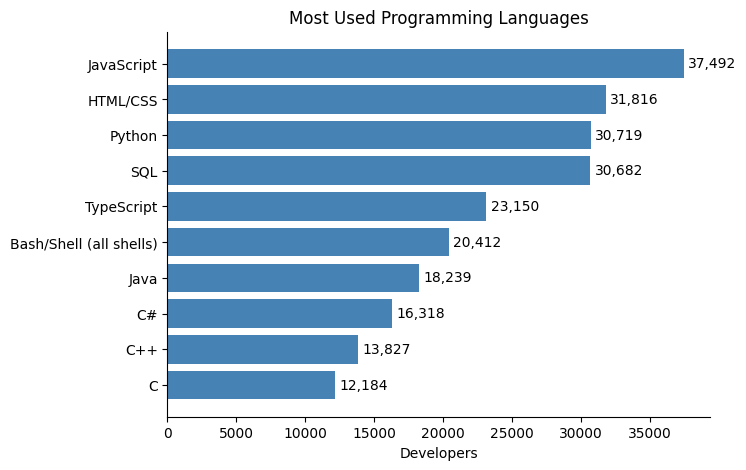

In [3]:
ax_lang_have = u.bars_plot(df_lang_metrics, 'HaveWorkedWith', 'Language', 'Most Used Programming Languages')
plt.show()

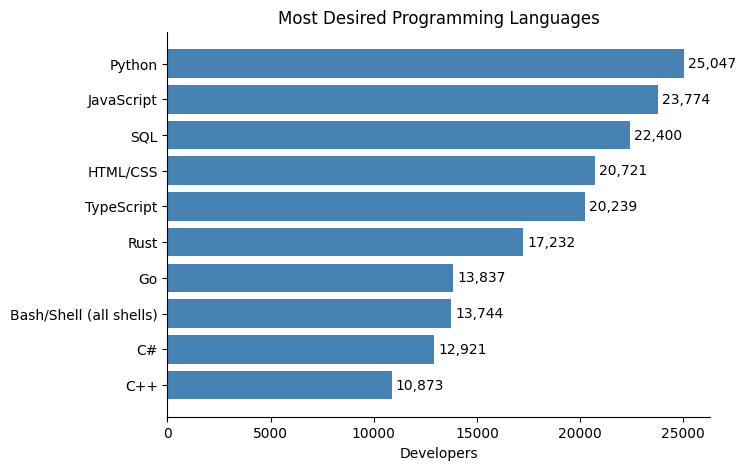

In [4]:
ax_lang_want = u.bars_plot(df_lang_metrics, 'WantToWorkWith', 'Language', 'Most Desired Programming Languages')
plt.show()

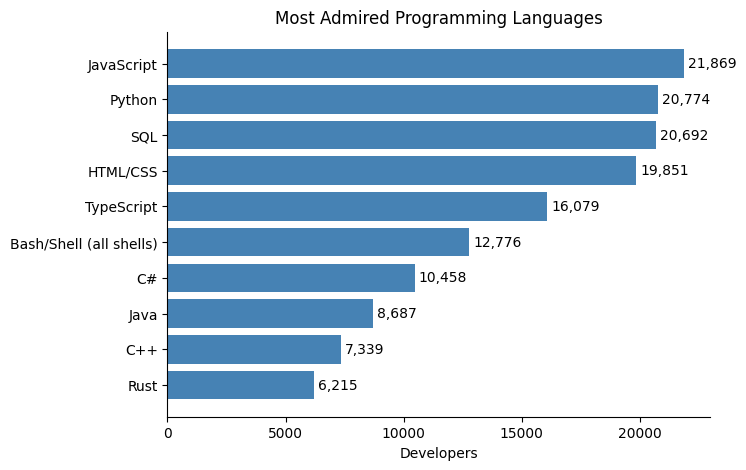

In [5]:
ax_lang_adm = u.bars_plot(df_lang_metrics, 'Admired', 'Language', 'Most Admired Programming Languages')
plt.show()

JavaScript se mantiene como el lenguaje más utilizado y también el más admirado por los desarrolladores durante el último año. Esto sugiere que continúa siendo el estándar dominante dentro de la industria, especialmente en desarrollo web.  

Por otro lado, Python ocupa el primer lugar en los lenguajes con los que los desarrolladores desean trabajar, lo que indica una fuerte tendencia aspiracional hacia áreas como ciencia de datos, automatización e inteligencia artificial.  

Al comparar los lenguajes usados, deseados y admirados, se observa que el Top 4 se mantiene consistente: JavaScript, Python, HTML/CSS y SQL. Esto refleja que el ecosistema de desarrollo actual se sostiene principalmente en tecnologías web y manejo de datos.  

Sin embargo, el orden cambia: JavaScript domina el presente laboral, mientras Python representa el interés futuro de los desarrolladores.

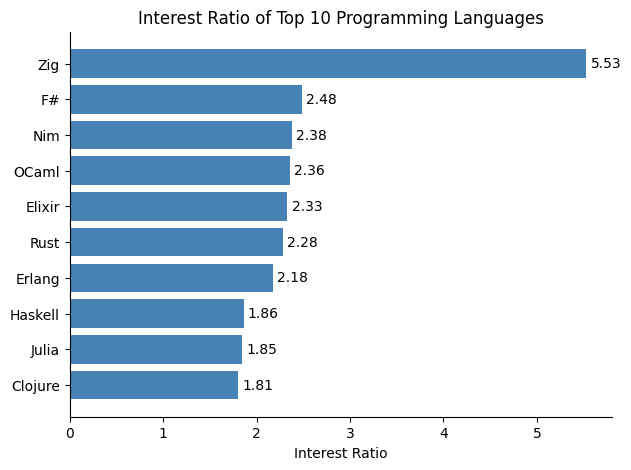

In [10]:
ax_interest_ratio = u.bars_plot(df_lang_metrics, 
                                'InterestRatio', 
                                'Language', 
                                'Interest Ratio of Top 10 Programming Languages', 
                                fmt = '{:.2f}', 
                                xlabel = 'Interest Ratio')
plt.show()

- Al analizar los coeficientes de interés de las tecnologías, Zig ocupa la primera posición con un valor de 5.53, lo que indica un nivel de interés significativamente superior en comparación con su base actual de usuarios.
- Asimismo, se observa que varias tecnologías fuera del "top 10 en uso" presentan coeficientes de interés mayores a 2, como F#, Nim, OCaml y Elixir, lo que sugiere un alto potencial de crecimiento a pesar de su baja adopción actual.

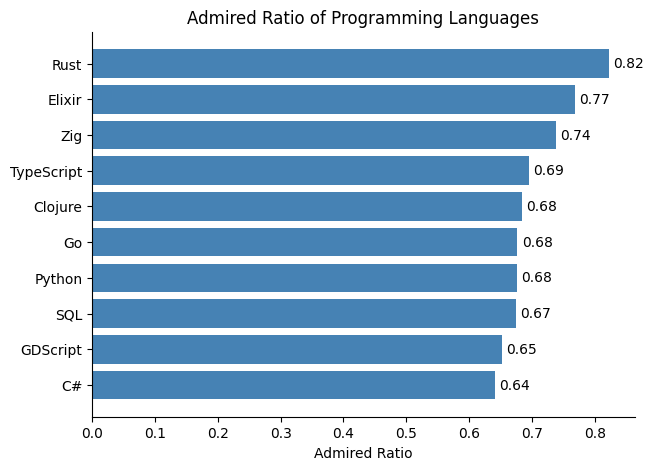

In [13]:
ax_adm_ratio = u.bars_plot(df_lang_metrics, 'AdmiredRatio', 'Language', 'Admired Ratio of Programming Languages', fmt = '{:.2f}', xlabel = 'Admired Ratio')
plt.show()

- Lenguajes como Rust, Elixir y Zig, aunque no se encuentran en el top 10 por uso, lideran en coeficiente de admiración, con valores superiores a 0.7. Esto sugiere que, a pesar de su menor base de usuarios, presentan un alto nivel de satisfacción y fidelidad entre quienes los utilizan.

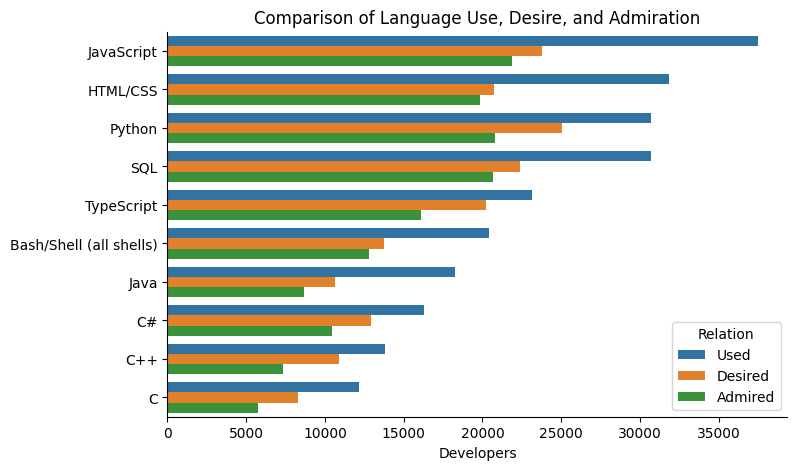

In [12]:
ax_comp = u.bar_comparative_plot(df_lang_metrics, 'Language', 'Comparison of Language Use, Desire, and Admiration')
plt.show()

- Aunque lenguajes como JavaScript, HTML/CSS y Python lideran en uso absoluto, la diferencia entre uso, interés y admiración evidencia dinámicas distintas entre tecnologías.
- Por un lado, lenguajes como TypeScript muestran una relación más equilibrada entre uso e interés, lo que sugiere una tendencia de crecimiento sostenido. En contraste, tecnologías como Java y C++ presentan una menor proporción de admiración respecto a su base de usuarios, lo que podría indicar menor satisfacción relativa.
- En general, los lenguajes más utilizados no necesariamente son los más valorados, lo que resalta la importancia de complementar el análisis con métricas relativas para evitar interpretaciones sesgadas.

## HaveWorkedWith vs InterestRatio

In [ ]:
x_median = df_lang_metrics['HaveWorkedWith'].median()
df_plot = u.assign_quadrant(
    df_lang_metrics, 
    'HaveWorkedWith', 
    'InterestRatio', 
    x_median, 
    1, 
    'MarketQuadrant',
    'Growth',
    'Emerging',
    'Declining',
    'Mature'
)

In [ ]:
growth   = df_plot[df_plot['MarketQuadrant'] == 'Growth'].nlargest(4, 'HaveWorkedWith')
emerging  = df_plot[df_plot['MarketQuadrant'] == 'Emerging'].nlargest(4, 'InterestRatio')
mature    = df_plot[df_plot['MarketQuadrant'] == 'Mature'].nlargest(4, 'HaveWorkedWith')
declining = df_plot[df_plot['MarketQuadrant'] == 'Declining'].nsmallest(4, 'InterestRatio')

label_df = pd.concat([growth, emerging, mature, declining])

In [ ]:
ax_have_interest = u.quadrant_chart(df_lang_metrics, 'HaveWorkedWith', 'InterestRatio', x_median, 1, label_df, 'Growth', 'Emerging', 'Declining', 'Mature')
plt.show()

El mercado de lenguajes de programación muestra una clara separación entre tecnologías consolidadas y tecnologías con potencial de crecimiento.  

- Lenguajes como Python, SQL y JavaScript mantienen una posición dominante debido a su amplia base instalada, lo que sugiere estabilidad y baja volatilidad en el corto plazo.  

- Lenguajes como Rust y Go presentan señales claras de expansión y alta lealtad entre sus usuarios, indicando potencial consolidación futura.  

- Lenguajes emergentes como Zig muestran altas tasas relativas de intención de adopción, aunque desde bases muy pequeñas, lo que representa oportunidades con mayor nivel de incertidumbre.  

- Lenguajes como Perl y Delphi parecen mantenerse principalmente por mantenimiento de sistemas existentes, con bajo dinamismo de crecimiento.  

## InterestRatio vs AdmiredRatio

In [ ]:
x_median = df_plot['InterestRatio'].median()
y_median = df_plot['AdmiredRatio'].median()

df_plot = u.assign_quadrant(
    df_plot,
    'InterestRatio',
    'AdmiredRatio',
    x_median,
    y_median,
    'PerceptionQuadrant',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

In [ ]:
leaders = df_plot[df_plot['PerceptionQuadrant'] =='Leaders'].nlargest(4, 'AdmiredRatio')
loved   = df_plot[df_plot['PerceptionQuadrant'] == 'Loved Niche'].nlargest(4, 'AdmiredRatio')
trendy  = df_plot[df_plot['PerceptionQuadrant'] == 'Trendy'].nlargest(4, 'InterestRatio')
weak    = df_plot[df_plot['PerceptionQuadrant'] == 'Weak'].nsmallest(4, 'AdmiredRatio')

label_df = pd.concat([leaders, loved, trendy, weak])

In [ ]:
ax_prefer_adm = u.quadrant_chart(
    df_plot,
    'InterestRatio',
    'AdmiredRatio',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

El análisis de intención de adopción y nivel de admiración revela una clara diferenciación en el posicionamiento de los lenguajes.  

- Un grupo reducido (Rust, Elixir, Zig, Clojure) combina alta satisfacción con fuerte intención de adopción, posicionándose como los mejor valorados del ecosistema.  
- Tecnologías consolidadas como Python, SQL y TypeScript mantienen altos niveles de admiración, aunque con crecimiento más estable.  
- Otros lenguajes muestran interés inicial sin consolidar alta lealtad (Trendy).  
- Finalmente, un grupo presenta bajo dinamismo en percepción, con reducida intención futura y baja admiración.

## Interest Rate vs Admired Rate

In [ ]:
x_median = df_plot['InterestRate'].quantile(0.75)
y_median = df_plot['AdmiredRate'].quantile(0.75)

df_plot = u.assign_quadrant(
    df_plot,
    'InterestRate',
    'AdmiredRate',
    x_median,
    y_median,
    'PerceptionQuadrant2',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

In [ ]:
leaders = df_plot[df_plot['PerceptionQuadrant2'] =='Leaders'].nlargest(4, 'AdmiredRate')
loved   = df_plot[df_plot['PerceptionQuadrant2'] == 'Loved Niche'].nlargest(4, 'AdmiredRate')
trendy  = df_plot[df_plot['PerceptionQuadrant2'] == 'Trendy'].nlargest(4, 'InterestRate')
weak    = df_plot[df_plot['PerceptionQuadrant2'] == 'Weak'].nsmallest(4, 'AdmiredRate')

label_df = pd.concat([leaders, loved, trendy, weak])

In [ ]:
ax_intr_admr = u.quadrant_chart(
    df_plot,
    'InterestRate',
    'AdmiredRate',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

## MarketQuadrant vs PerceptionQuadrant

In [ ]:
comparison = (
    df_plot[
        ['MarketQuadrant', 'PerceptionQuadrant']
    ]
    .reset_index()
    .sort_values(['MarketQuadrant', 'PerceptionQuadrant'])
)

crosstab = pd.crosstab(
    df_plot['MarketQuadrant'],
    df_plot['PerceptionQuadrant']
)

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab_pct

- Existe una fuerte alineación entre percepción positiva y crecimiento estructural.  
- Las tecnologías en expansión son consistentemente percibidas como líderes, mientras que aquellas en declive concentran percepciones débiles.
- Las tecnologías maduras muestran polarización: algunas mantienen alta valoración, mientras otras sobreviven sin dinamismo estratégico.

El análisis evidencia que la percepción positiva del desarrollador es un predictor clave del crecimiento tecnológico.  
Las tecnologías con alta admiración e intención relativa muestran mayor probabilidad de expansión estructural, mientras que aquellas con baja percepción tienden al estancamiento o declive.  
Por lo tanto, las decisiones estratégicas de capacitación e inversión deberían equilibrar estabilidad operativa con exploración selectiva de tecnologías emergentes altamente valoradas.

## Technologies by Opportunity Score

In [ ]:
market_score = {
    'Growth': 3,
    'Emerging': 2,
    'Mature': 1,
    'Declining': 0
}

perception_score = {
    'Leaders': 3,
    'Loved Niche': 2,
    'Trendy': 1,
    'Weak': 0
}

df_plot['MarketScore'] = df_plot['MarketQuadrant'].map(market_score)
df_plot['PerceptionScore'] = df_plot['PerceptionQuadrant'].map(perception_score)

In [ ]:
df_plot["OpportunityScore"] = (
    df_plot["MarketScore"] * 0.6 +
    df_plot["PerceptionScore"] * 0.4
)

ranking = (
    df_plot
    .sort_values("OpportunityScore", ascending=False).reset_index()
    [["Language","MarketQuadrant","PerceptionQuadrant","OpportunityScore"]]
)

top = 15

df_rank = (
    df_plot
    .sort_values("OpportunityScore", ascending=False)
    .head(top)
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=df_rank,
    x="OpportunityScore",
    y="Language"
)

plt.title("Top Technologies by Opportunity Score")
plt.xlabel("Opportunity Score")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
pivot = (
    df_plot
    .pivot_table(
        values="OpportunityScore",
        index="MarketQuadrant",
        columns="PerceptionQuadrant"
    )
)

sns.heatmap(pivot, annot=True, cmap="YlGnBu")

In [ ]:
df_plot["AlignmentGap"] = (
    df_plot["PerceptionScore"] - df_plot["MarketScore"]
)

df_plot.sort_values("AlignmentGap", ascending=False)['AlignmentGap'].head(5)

Lenguajes como Lua y Erlang presentan una percepción significativamente superior a su posición actual en el mercado, lo que indica una posible oportunidad de crecimiento impulsada por entusiasmo y admiración de la comunidad.

In [ ]:
df_plot.sort_values("AlignmentGap")['AlignmentGap'].head(5)

Lenguajes como C y MATLAB muestran una posición de mercado sólida pero una percepción débil, lo que podría representar un riesgo de pérdida de atractivo futuro si no se renueva su ecosistema o propuesta de valor.

In [ ]:
df_lang_exp = (
    df_languages
    .merge(df_respondents[['ResponseId', 'YearsCodePro', 'Age_Group', 'RemoteWork_Clean', 'EdLevel_Group', 'Country']], on="ResponseId")
)
df_lang_exp.head()

In [ ]:
df_analysis = df_lang_exp.merge(
    df_plot.reset_index()[['Language', 'MarketQuadrant', 'PerceptionQuadrant', 
             'MarketScore', 'PerceptionScore', 'OpportunityScore', 'AlignmentGap']],
    on = 'Language',
    how = 'left'
)
df_analysis.head()

In [ ]:
df_analysis['MarketQuadrant'].isna().sum()

In [ ]:
df_plot.reset_index()['Language'].nunique() == len(df_plot)

In [ ]:
len(df_lang_exp) == len(df_analysis)

In [ ]:
(
    df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']
    .groupby('MarketQuadrant')['YearsCodePro']
    .mean()
    .sort_values()
)

Las tecnologías clasificadas como Declining presentan el mayor promedio de experiencia profesional (~16 años). Esto sugiere que su uso se concentra principalmente en desarrolladores senior que mantienen sistemas existentes.  

En contraste, las tecnologías Growth, Mature y Emerging muestran promedios cercanos a los 9–10 años de experiencia, lo que indica una adopción más equilibrada entre distintos niveles de seniority.

In [ ]:
sns.boxplot(
    data=df_analysis[df_analysis['Relation'] == 'HaveWorkedWith'],
    x = 'YearsCodePro',
    y = 'MarketQuadrant'
)
plt.show()

- Las tecnologías Declining concentran desarrolladores con más experiencia
- Las tecnologías Growth, Mature y Emerging tienen perfiles de experiencia muy similares
- La mayoría de desarrolladores en todas las categorías tiene menos de 15 años de experiencia

In [ ]:
df_plot2 = df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']

plt.figure(figsize=(10,6))

sns.kdeplot(
    data = df_plot2,
    x = 'YearsCodePro',
    hue = 'MarketQuadrant',
    common_norm = False,
    fill = True,
    alpha = 0.35,
    cut = 0
)
plt.xlim(0,50)
plt.xlabel('Years of Professional Coding')
plt.ylabel('Density')
plt.title('Experience Distribution by Market Quadrant')
plt.show()

La distribución de la experiencia profesional en programación muestra que la mayoría de los desarrolladores que utilizan tecnologías en los cuadrantes de Crecimiento, Madurez y Emergente tienen entre 3 y 10 años de experiencia.  

En cambio, las tecnologías clasificadas como En Declive presentan una distribución que se desplaza hacia niveles de experiencia más altos, lo que sugiere que son más utilizadas por desarrolladores sénior que mantienen sistemas heredados.

In [ ]:
pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize = 'index'
)

In [ ]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize = 'index'
)

ct.plot(
    kind = 'bar',
    stacked = True,
    figsize = (10,6)
)
order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Perception of Technologies by Age Group')
plt.legend(title = 'Perception Quadrant')
plt.show()

In [ ]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize = 'index'
)

order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

ct.plot(
    kind = 'line',
    marker = 'o',
    figsize = (10,6)
)

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Technology Perception Trends by Age')
plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(
    ct,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Perception Quadrant by Age Group")
plt.ylabel("Age Group")
plt.xlabel("Perception Quadrant")
plt.show()

- La mayoría de las tecnologías son percibidas como Loved Niche independientemente de la edad.
- Los desarrolladores más jóvenes perciben una mayor proporción de tecnologías como líderes.
- Los desarrolladores de mayor edad tienden a clasificar más tecnologías como débiles.
- Pocas tecnologías se perciben como Trendy en comparación con las otras categorías.
- La percepción del mercado tecnológico se vuelve más crítica con la experiencia.

In [ ]:
(
    df_analysis[df_analysis["Relation"]=="WantToWorkWith"]
    .groupby("Age_Group")["AlignmentGap"]
    .mean()
)

In [ ]:
gap_age = (
    df_analysis[df_analysis["Relation"]=="WantToWorkWith"]
    .groupby("Age_Group")["AlignmentGap"]
    .mean()
)

order = ["Under 18","18-24","25-34","35-44","45-54","55-64","65+","Unknown"]
gap_age = gap_age.loc[order]

gap_age.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.ylabel("Average Alignment Gap")
plt.xlabel("Age Group")
plt.title("Alignment Gap by Age Group")
plt.show()

Los desarrolladores más jóvenes y de media carrera tienden a querer trabajar con tecnologías menos alineadas con el mercado actual, mientras que los desarrolladores más senior muestran preferencias más alineadas con las tecnologías ya utilizadas.

In [ ]:
df_user_gap = (
    df_analysis[df_analysis["Relation"]=="WantToWorkWith"]
    .groupby("ResponseId")["AlignmentGap"]
    .mean()
    .reset_index()
)

df_user_gap = df_user_gap.merge(
    df_respondents[["ResponseId","Age_Group"]],
    on="ResponseId"
)

df_user_gap.groupby("Age_Group")["AlignmentGap"].mean()

In [ ]:
df_plot[['Admired', 'HaveWorkedWith', 'WantToWorkWith', 'InterestRate', 'AdmiredRate', 'OpportunityScore']].corr()